# IPL Data Analysis

The Indian Premier League is one of the most watched cricket tournaments in the world.
In this project, I have analyzed IPL match data from 2008 to 2022 to find
interesting patterns around team performance, player stats, toss decisions, and venues.

**Dataset:** IPL Complete Dataset — Kaggle  
**Tools used:** Python, Pandas, Matplotlib, Seaborn  


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv('deliveries.csv')

### Data Overview

In [5]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [8]:
matches.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
count,636.000000,636.000000,636.000000,636.000000,636.000000,0.0
mean,318.500000,2012.490566,0.025157,13.682390,3.372642,NaN
std,183.741666,2.773026,0.156726,23.908877,3.420338,NaN
min,1.000000,2008.000000,0.000000,0.000000,0.000000,NaN
25%,159.750000,2010.000000,0.000000,0.000000,0.000000,NaN
50%,318.500000,2012.000000,0.000000,0.000000,4.000000,NaN
75%,477.250000,2015.000000,0.000000,20.000000,7.000000,NaN
max,636.000000,2017.000000,1.000000,146.000000,10.000000,NaN


### Data Cleaning

In [9]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [13]:
# umpire3 column is mostly empty, not useful for analysis so dropping it 
if 'umpire3' in matches.columns:
    matches.drop(columns=['umpire3'],inplace=True)

# Fixing the team names changed over the years 
team_name_map={
    'Delhi Capitals': 'Delhi Daredevils',
    'Kings XI Punjab': 'Punjab Kings'
}

for col in ['team1','team2','winner','toss_winner']: 
    matches[col]=matches[col].replace(team_name_map)

# Checking duplicates
print("Duplicate rows in matches:",matches.duplicated().sum())
print('Duplicatte rows in deliveries : ',deliveries.duplicated().sum())



Duplicate rows in matches: 0
Duplicatte rows in deliveries :  1


### Team Performance Analysis

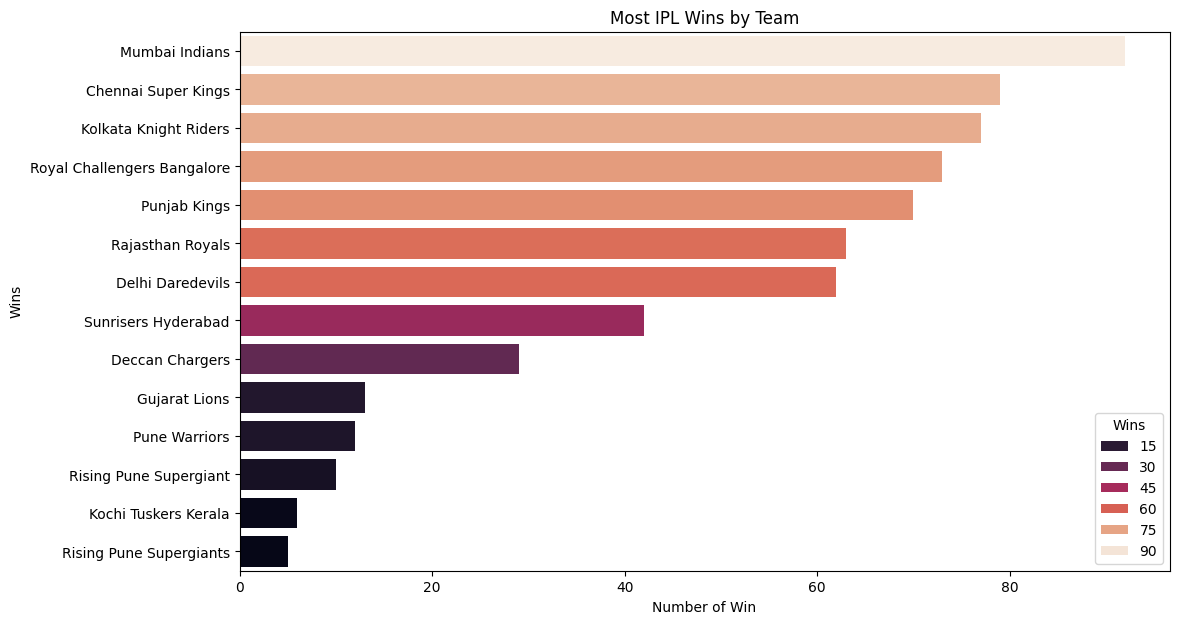

In [18]:
champions=matches['winner'].value_counts().reset_index()
champions.columns=['Team','Wins']
champions=champions.sort_values('Wins',ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Wins',y='Team',data=champions,hue='Wins',palette='rocket')
plt.title('Most IPL Wins by Team')
plt.xlabel('Number of Win')
plt.ylabel('Wins')
plt.show()

Mumbai Indians has the most wins overall, followed closely by Chennai Super Kings.
These two teams have consistently been the strongest franchises throughout IPL history.

### Toss Impact Chart

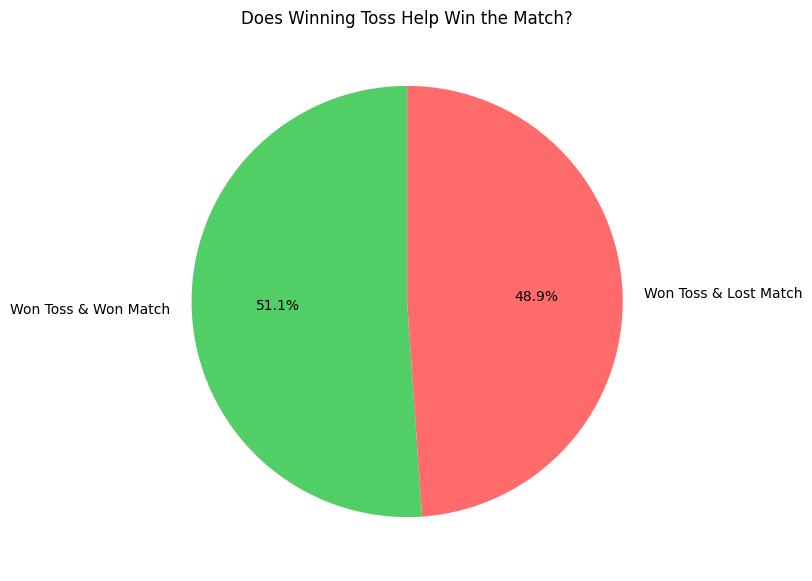

In [24]:
matches['toss_match_win']=(matches['toss_winner']==matches['winner'])
toss_impact=matches['toss_match_win'].value_counts()

plt.figure(figsize=(12,7))
plt.pie(
    toss_impact,
    labels=['Won Toss & Won Match','Won Toss & Lost Match'],
    autopct='%1.1f%%',
    colors=['#51cf66', '#ff6b6b'],
    startangle=90
)
plt.title('Does Winning Toss Help Win the Match?')
plt.show()

Winning the toss gives only a slight advantage of around 52%. 
This means toss barely decides the outcome of a match.

### Player of the Match Analysis

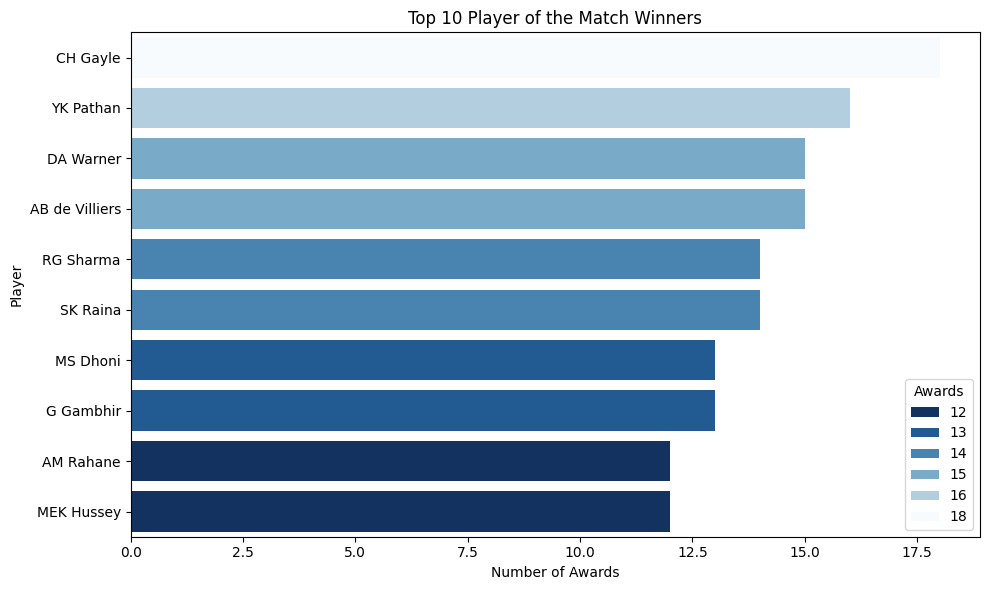

In [26]:
top_players = matches['player_of_match'].value_counts().head(10).reset_index()
top_players.columns = ['Player', 'Awards']

plt.figure(figsize=(10, 6))
sns.barplot(x='Awards', y='Player', data=top_players, hue='Awards',palette='Blues_r')

plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

AB de Villiers and Chris Gayle have won the most Player of the Match awards,
reflecting their ability to single-handedly change the course of a match.

### Top Run Scorers

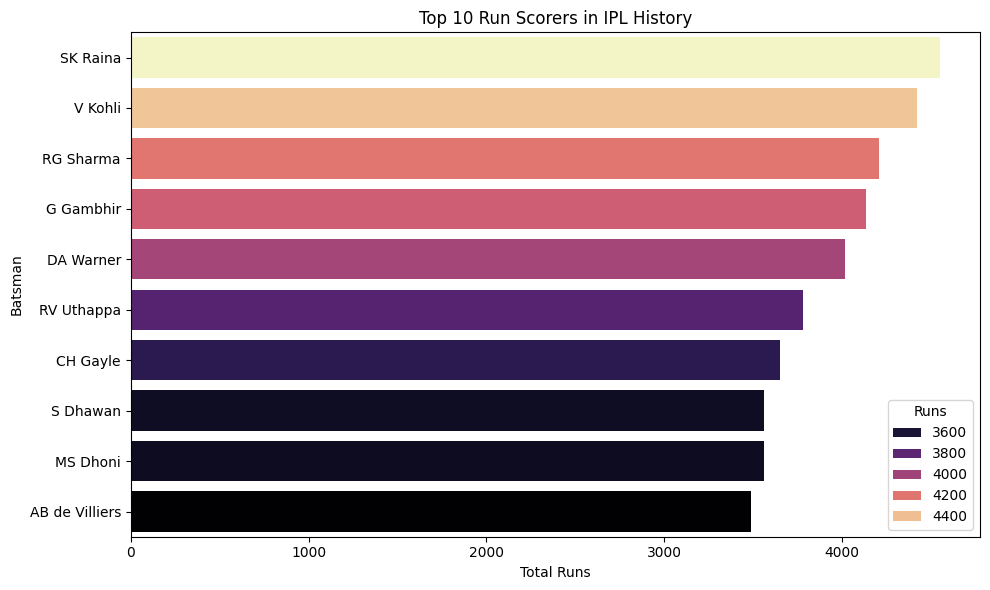

In [30]:
top_batsmen = (
    deliveries.groupby('batsman')['batsman_runs']
    .sum()
    .reset_index()
    .sort_values('batsman_runs', ascending=False)
    .head(10)
)
top_batsmen.columns = ['Batsman', 'Runs']

plt.figure(figsize=(10, 6))
sns.barplot(x='Runs', y='Batsman', data=top_batsmen, hue='Runs', palette='magma')

plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

Virat Kohli is the all time leading run scorer in IPL history.
His consistency across every season is what separates him from the rest.

### Top Wicket Takers

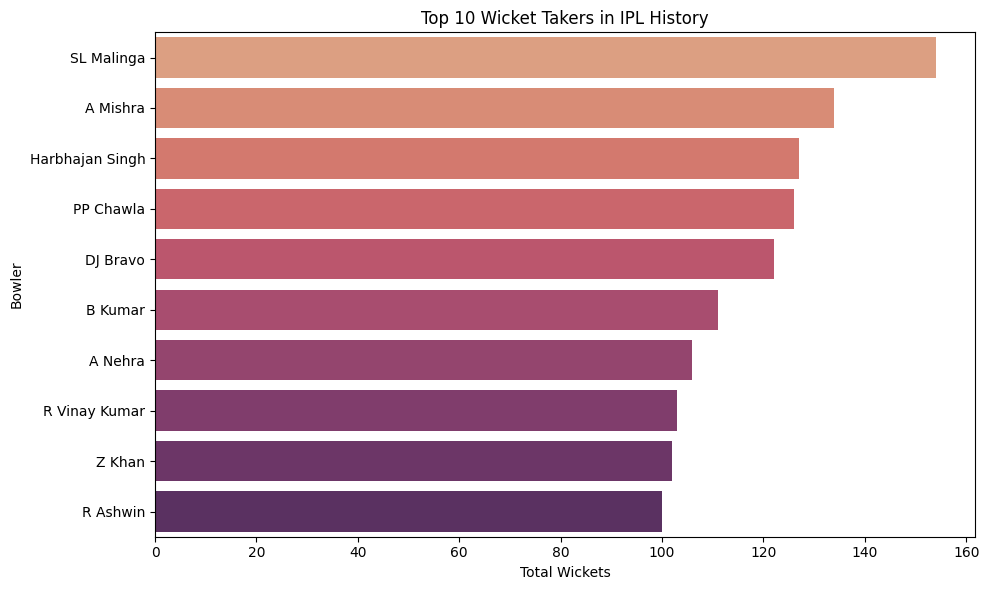

In [32]:
bowler_wickets = deliveries[
    deliveries['dismissal_kind'].notna() &
    ~deliveries['dismissal_kind'].isin(['run out', 'retired hurt'])
]

top_bowlers = (
    bowler_wickets.groupby('bowler')['dismissal_kind']
    .count()
    .reset_index()
    .rename(columns={'dismissal_kind': 'Wickets', 'bowler': 'Bowler'})
    .sort_values('Wickets', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Wickets', y='Bowler', data=top_bowlers, hue='Bowler', palette='flare')

plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

Lasith Malinga leads the wicket takers chart by a big margin.
His ability to bowl yorkers consistently at the death made him
the most dangerous bowler in IPL history.

### Key Inshights

Most Succesful Team - Mumbai Indians\
Top Ru Scorer - Virat Kohli\
Top Wicket Taker - Lasith Malinga\
Most Player of the Match - AB de Villiers\
Toss Advantage - Only 52% - barey matters\
Preferred Toss Decision - Field First\
Busiest Venue - Wankhede Stadium , Mumbai

### Conclusion


This analysis covered over 800 matches and roughly 200,000 deliveries
across 10+ IPL seasons.

A few things stood out during the analysis. Mumbai Indians and Chennai
Super Kings have been consistently dominant — no other team comes close
to their win counts. The toss turned out to be far less important than
most people assume, with only a 52% advantage. Virat Kohli's run tally
is in a league of its own, and Lasith Malinga's wicket count reflects
how lethal he was across every season he played.

Overall this was a great dataset to work with. The ball by ball data
in deliveries.csv especially opens up a lot of deeper analysis
possibilities beyond what I have covered here.

### What I Would Explore Next

- Predict match winners using machine learning based on toss, venue and teams
- Powerplay vs death over run rate comparison for each team
- Season wise performance trend for individual players
- Head to head records between all team combinations

### References

- Dataset : IPL Complete Dataset - Kaggle
- Data covers IPL Seasons from 2008 to 2022